In [42]:
!pip -q install lifelines
!pip install gseapy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 16.8 MB/s eta 0:00:00


In [43]:
import os, json
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from lifelines.utils import concordance_index
import gseapy as gp

In [44]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Attention-Rank Comparison

In [3]:
# Load gene ranking tables
residual_df = pd.read_csv("/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv/residual_gate_summary.csv")
gated_df    = pd.read_csv("/content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv/gate_summary.csv")


# Rename score columns to avoid collision after merge
residual_df = residual_df.rename(columns={
    "mean_gate_score": "residual_score",
    "std_gate_score": "residual_std"
})

gated_df = gated_df.rename(columns={
    "mean_gate_score": "gated_score",
    "std_gate_score": "gated_std"
})

In [4]:
# Merge by gene
compare_df = residual_df.merge(gated_df, on="gene", how="inner")

print("Merged shape:", compare_df.shape)
print(compare_df.head())


# Create ranks
compare_df["residual_rank"] = compare_df["residual_score"].rank(ascending=False, method="average")
compare_df["gated_rank"] = compare_df["gated_score"].rank(ascending=False, method="average")

# Rank difference
compare_df["rank_diff"] = compare_df["residual_rank"] - compare_df["gated_rank"]
compare_df["abs_rank_diff"] = compare_df["rank_diff"].abs()

# Sort by one model
compare_df = compare_df.sort_values("residual_rank").reset_index(drop=True)

# Save table
compare_df.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/gate_rank_comparison_full.csv", index=False)

Merged shape: (3000, 5)
        gene  residual_score  residual_std  gated_score  gated_std
0       FGF2        0.790498      0.091650     0.505563   0.083531
1      TRIP6        0.744004      0.095981     0.507820   0.147654
2    SULT1E1        0.729820      0.114513     0.679527   0.099377
3       PSAP        0.725543      0.130397     0.567941   0.077893
4  LOC389834        0.725013      0.119775     0.672009   0.078974


In [5]:
# Test global similarity
spearman_corr, spearman_p = spearmanr(compare_df["residual_rank"], compare_df["gated_rank"])
pearson_corr, pearson_p   = pearsonr(compare_df["residual_score"], compare_df["gated_score"])

print(f"Spearman correlation (rank vs rank): {spearman_corr:.4f}, p = {spearman_p:.4e}")
print(f"Pearson correlation (score vs score): {pearson_corr:.4f}, p = {pearson_p:.4e}")

Spearman correlation (rank vs rank): 0.0677, p = 2.0819e-04
Pearson correlation (score vs score): 0.0710, p = 1.0026e-04


In [6]:
# Check top-k overlap genes
def top_k_overlap(df, k):
    top_residual = set(df.nsmallest(k, "residual_rank")["gene"])
    top_gated    = set(df.nsmallest(k, "gated_rank")["gene"])

    overlap = top_residual & top_gated
    union   = top_residual | top_gated
    jaccard = len(overlap) / len(union) if len(union) > 0 else np.nan

    return {
        "k": k,
        "shared_genes": len(overlap),
        "overlap_rate_vs_k": len(overlap) / k,
        "jaccard_index": jaccard
    }

overlap_results = pd.DataFrame([top_k_overlap(compare_df, k) for k in [10, 20, 50, 100, 200, 500]])

print("\nTop-k overlap:")
print(overlap_results)

# Save table
overlap_results.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/topk_overlap_summary.csv", index=False)


Top-k overlap:
     k  shared_genes  overlap_rate_vs_k  jaccard_index
0   10             0              0.000       0.000000
1   20             0              0.000       0.000000
2   50             3              0.060       0.030928
3  100             9              0.090       0.047120
4  200            19              0.095       0.049869
5  500           105              0.210       0.117318


In [7]:
# Candidate gene sets
top100_residual = set(compare_df.nsmallest(100, "residual_rank")["gene"])
top100_gated    = set(compare_df.nsmallest(100, "gated_rank")["gene"])

shared_top100 = sorted(top100_residual & top100_gated)
residual_only_top100 = sorted(top100_residual - top100_gated)
gated_only_top100 = sorted(top100_gated - top100_residual)

top500_residual = set(compare_df.nsmallest(500, "residual_rank")["gene"])
top500_gated    = set(compare_df.nsmallest(500, "gated_rank")["gene"])
shared_top500 = sorted(top500_residual & top500_gated)

candidate_df = pd.DataFrame({"gene": sorted(set(shared_top100 + residual_only_top100 + gated_only_top100 + shared_top500))})

candidate_df["shared_top100"] = candidate_df["gene"].isin(shared_top100)
candidate_df["residual_only_top100"] = candidate_df["gene"].isin(residual_only_top100)
candidate_df["gated_only_top100"] = candidate_df["gene"].isin(gated_only_top100)
candidate_df["shared_top500"] = candidate_df["gene"].isin(shared_top500)

candidate_df.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/candidate_gene_sets.csv", index=False)

print(candidate_df.shape)
candidate_df.head()

(254, 5)


,gene,shared_top100,residual_only_top100,gated_only_top100,shared_top500
0,ABCA12,False,True,False,True
1,ABCF2,False,False,True,False
2,ABCG5,False,False,True,False
3,ABHD12,False,False,True,False
4,ACSM1,False,False,True,False


In [8]:
# Merge attention information
validation_df = compare_df.merge(candidate_df, on="gene", how="left")

for col in ["shared_top100", "residual_only_top100", "gated_only_top100", "shared_top500"]:
    validation_df[col] = validation_df[col].fillna(False)

validation_df.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/combined_validation_table_attention.csv", index=False)
validation_df.head()

/tmp/ipykernel_2901/1667322169.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_df[col] = validation_df[col].fillna(False)


,gene,residual_score,residual_std,gated_score,gated_std,residual_rank,gated_rank,rank_diff,abs_rank_diff,shared_top100,residual_only_top100,gated_only_top100,shared_top500
0,FGF2,0.790498,0.091650,0.505563,0.083531,1.0,1689.0,-1688.0,1688.0,False,True,False,False
1,TRIP6,0.744004,0.095981,0.507820,0.147654,2.0,1660.0,-1658.0,1658.0,False,True,False,False
2,SULT1E1,0.729820,0.114513,0.679527,0.099377,3.0,22.0,-19.0,19.0,True,False,False,True
3,PSAP,0.725543,0.130397,0.567941,0.077893,4.0,722.0,-718.0,718.0,False,True,False,False
4,LOC389834,0.725013,0.119775,0.672009,0.078974,5.0,37.0,-32.0,32.0,True,False,False,True


In [9]:
# Genes with biggest rank shifts
largest_shifts = compare_df.sort_values("abs_rank_diff", ascending=False).head(30)
#largest_shifts.to_csv("largest_rank_shifts.csv", index=False)

print("\nTop 20 genes with largest rank differences:")
print(largest_shifts[[
    "gene", "residual_score", "gated_score",
    "residual_rank", "gated_rank", "rank_diff", "abs_rank_diff"
]].head(20))


Top 20 genes with largest rank differences:
              gene  residual_score  gated_score  residual_rank  gated_rank  \
2942  LOC105378146        0.352298     0.684394         2943.0        17.0   
2986        EIF2B2        0.324317     0.649441         2987.0        79.0   
37           PSMD8        0.685277     0.380006           38.0      2941.0   
2905        IFNA10        0.369028     0.691258         2906.0        14.0   
2976          NKRF        0.335750     0.639467         2977.0       113.0   
158          TULP1        0.637848     0.365799          159.0      2973.0   
2889         LENG1        0.373929     0.651650         2890.0        76.0   
2845         KPNA2        0.385638     0.669651         2846.0        41.0   
6            REG1A        0.721626     0.411239            7.0      2809.0   
107          FANK1        0.656332     0.390522          108.0      2901.0   
2877         KCNT1        0.377213     0.646123         2878.0        87.0   
41        SERPINE1 

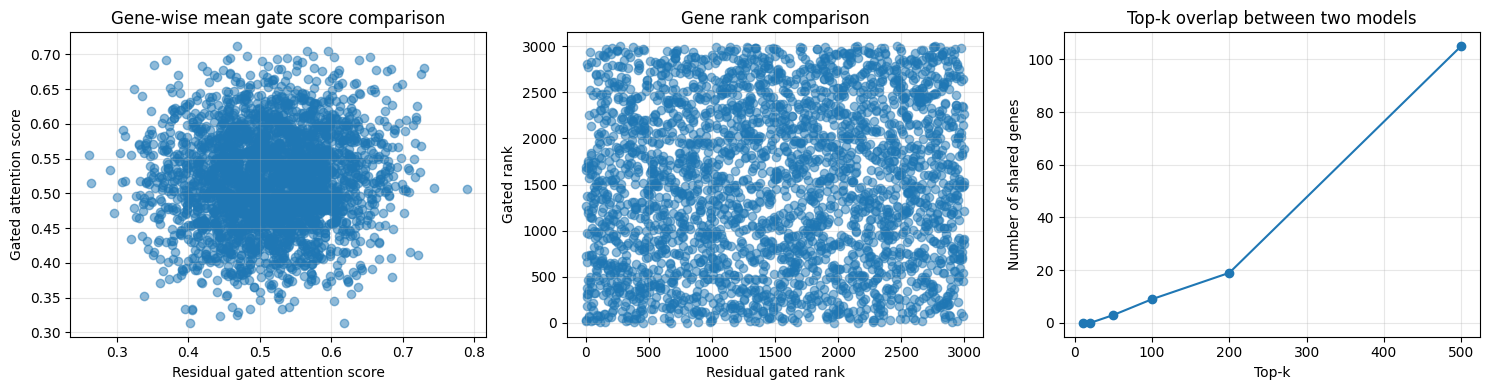

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Plot Score vs score scatter
ax[0].scatter(compare_df["residual_score"], compare_df["gated_score"], alpha=0.5)
ax[0].set_xlabel("Residual gated attention score")
ax[0].set_ylabel("Gated attention score")
ax[0].set_title("Gene-wise mean gate score comparison")
ax[0].grid(True, alpha=0.3)


# Plot Rank vs rank scatter
ax[1].scatter(compare_df["residual_rank"], compare_df["gated_rank"], alpha=0.5)
ax[1].set_xlabel("Residual gated rank")
ax[1].set_ylabel("Gated rank")
ax[1].set_title("Gene rank comparison")
ax[1].grid(True, alpha=0.3)

# Plot Top overlap curve
ax[2].plot(overlap_results["k"], overlap_results["shared_genes"], marker="o")
ax[2].set_xlabel("Top-k")
ax[2].set_ylabel("Number of shared genes")
ax[2].set_title("Top-k overlap between two models")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Cox PH Gene Ranking Comparison

In [11]:
# Load Cox PH model result
cox_df = pd.read_csv("/content/drive/MyDrive/ECEN766final/CoxPH/cox_coefficients_sorted.csv")

cox_df = cox_df.reset_index().rename(columns={
    "covariate": "gene",
    "coef": "cox_coef",
    "exp(coef)": "cox_HR",
    "p": "cox_p"
})

cox_df["cox_abs_logHR"] = cox_df["cox_coef"].abs()

In [12]:
# Add False discovery rate correction p-value (test of whether the gene is statistically supported)
from statsmodels.stats.multitest import multipletests

valid_p = cox_df["cox_p"].notna()

cox_df.loc[valid_p, "cox_FDR"] = multipletests(
    cox_df.loc[valid_p, "cox_p"],
    method="fdr_bh"
)[1]

# Add Cox rank
# Rank by effect size (strongest survival effect to weak)
cox_df["cox_rank_abs_logHR"] = cox_df["cox_abs_logHR"].rank(ascending=False, method="average")
# Rank by significance (most statistically significant to no evidence)
cox_df["cox_rank_p"] = cox_df["cox_p"].rank(ascending=True, method="average")

cox_df.head()

,index,gene,cox_coef,cox_HR,se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,cox_p,-log2(p),cox_abs_logHR,cox_FDR,cox_rank_abs_logHR,cox_rank_p
0,0,PACRG,0.038254,1.038995,0.024278,-0.009331,0.085839,0.990713,1.089630,0.0,1.575647,0.115107,3.118951,0.038254,0.999935,1.0,1.0
1,1,LIPK,0.030967,1.031451,0.023886,-0.015849,0.077782,0.984276,1.080887,0.0,1.296436,0.194825,2.359746,0.030967,0.999935,7.0,6.0
2,2,HBCBP,0.030056,1.030512,0.024011,-0.017005,0.077116,0.983139,1.080168,0.0,1.251751,0.210661,2.247007,0.030056,0.999935,11.0,12.0
3,3,MAP1B,0.030038,1.030494,0.025090,-0.019137,0.079214,0.981045,1.082436,0.0,1.197227,0.231218,2.112673,0.030038,0.999935,12.0,22.0
4,4,C2orf84,0.029806,1.030255,0.023712,-0.016669,0.076282,0.983469,1.079266,0.0,1.256998,0.208755,2.260121,0.029806,0.999935,13.0,11.0


In [13]:
# Merge with the attention comparison table
cox_compare_df = validation_df.merge(cox_df, on="gene", how="left")

print("Cox genes:", cox_df["gene"].nunique())
print("Attention genes:", validation_df["gene"].nunique())

matched = validation_df["gene"].isin(cox_df["gene"]).sum()
print("Matched genes:", matched)
print("Match rate:", matched / validation_df["gene"].nunique())

cox_compare_df.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/combined_validation_table_attention_cox.csv", index=False)

Cox genes: 3000
Attention genes: 3000
Matched genes: 3000
Match rate: 1.0


In [15]:
cox_compare_df.head(5)

,gene,residual_score,residual_std,gated_score,gated_std,residual_rank,gated_rank,rank_diff,abs_rank_diff,shared_top100,...,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,cox_p,-log2(p),cox_abs_logHR,cox_FDR,cox_rank_abs_logHR,cox_rank_p
0,FGF2,0.790498,0.091650,0.505563,0.083531,1.0,1689.0,-1688.0,1688.0,False,...,0.977238,1.074757,0.0,1.011086,0.311975,1.680497,0.024535,0.999935,56.0,57.0
1,TRIP6,0.744004,0.095981,0.507820,0.147654,2.0,1660.0,-1658.0,1658.0,False,...,0.947537,1.044698,0.0,-0.204035,0.838326,0.254417,0.005081,0.999935,1757.0,1750.0
2,SULT1E1,0.729820,0.114513,0.679527,0.099377,3.0,22.0,-19.0,19.0,True,...,0.960700,1.055175,0.0,0.284448,0.776067,0.365747,0.006807,0.999935,1380.0,1346.0
3,PSAP,0.725543,0.130397,0.567941,0.077893,4.0,722.0,-718.0,718.0,False,...,0.957096,1.056399,0.0,0.218674,0.826904,0.274208,0.005507,0.999935,1654.0,1670.0
4,LOC389834,0.725013,0.119775,0.672009,0.078974,5.0,37.0,-32.0,32.0,True,...,0.962821,1.058434,0.0,0.391320,0.695561,0.523752,0.009452,0.999935,929.0,891.0


In [16]:
# Compare attention with Cox effect-size rank and p-value rank
# Keep complete rows
cox_valid = cox_compare_df.dropna(subset=["residual_rank", "gated_rank", "cox_rank_abs_logHR", "cox_rank_p"]).copy()

# Spearman comparisons
comparisons = []

for attn_col, model_name in [
    ("residual_rank", "Residual Gated Attention"),
    ("gated_rank", "Gated Attention")
]:
    for cox_col, cox_name in [
        ("cox_rank_abs_logHR", "Cox abs(logHR) rank"),
        ("cox_rank_p", "Cox p-value rank")
    ]:
        corr, pval = spearmanr(cox_valid[attn_col], cox_valid[cox_col])
        comparisons.append({
            "attention_model": model_name,
            "attention_rank": attn_col,
            "cox_reference": cox_name,
            "cox_rank": cox_col,
            "spearman_corr": corr,
            "p_value": pval
        })

cox_attention_corr_df = pd.DataFrame(comparisons)
print(cox_attention_corr_df)

cox_attention_corr_df.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/cox_attention_rank_correlations.csv", index=False)

            attention_model attention_rank        cox_reference  \
0  Residual Gated Attention  residual_rank  Cox abs(logHR) rank   
1  Residual Gated Attention  residual_rank     Cox p-value rank   
2           Gated Attention     gated_rank  Cox abs(logHR) rank   
3           Gated Attention     gated_rank     Cox p-value rank   

             cox_rank  spearman_corr       p_value  
0  cox_rank_abs_logHR       0.113376  4.744034e-10  
1          cox_rank_p       0.115821  1.984413e-10  
2  cox_rank_abs_logHR       0.141704  6.310447e-15  
3          cox_rank_p       0.142697  4.069412e-15  


In [17]:
# Top-k overlap between attention genes and Cox genes
def topk_overlap_between_rankings(df, rank_col_1, rank_col_2, k_values=[10, 20, 50, 100, 200, 500]):
    results = []

    for k in k_values:
        top_1 = set(df.nsmallest(k, rank_col_1)["gene"])
        top_2 = set(df.nsmallest(k, rank_col_2)["gene"])

        overlap = top_1 & top_2
        union = top_1 | top_2

        results.append({
            "rank_1": rank_col_1,
            "rank_2": rank_col_2,
            "k": k,
            "shared_genes": len(overlap),
            "overlap_rate_vs_k": len(overlap) / k,
            "jaccard_index": len(overlap) / len(union) if len(union) > 0 else np.nan
        })

    return pd.DataFrame(results)


overlap_tables = []

for attn_col in ["residual_rank", "gated_rank"]:
    for cox_col in ["cox_rank_abs_logHR", "cox_rank_p"]:
        overlap_tables.append(
            topk_overlap_between_rankings(cox_valid, attn_col, cox_col)
        )

cox_attention_overlap_df = pd.concat(overlap_tables, ignore_index=True)

print(cox_attention_overlap_df)

cox_attention_overlap_df.to_csv("/content/drive/MyDrive/ECEN766final/GeneImportance/cox_attention_topk_overlap.csv", index=False)

           rank_1              rank_2    k  shared_genes  overlap_rate_vs_k  \
0   residual_rank  cox_rank_abs_logHR   10             0              0.000   
1   residual_rank  cox_rank_abs_logHR   20             0              0.000   
2   residual_rank  cox_rank_abs_logHR   50             0              0.000   
3   residual_rank  cox_rank_abs_logHR  100             9              0.090   
4   residual_rank  cox_rank_abs_logHR  200            32              0.160   
5   residual_rank  cox_rank_abs_logHR  500           120              0.240   
6   residual_rank          cox_rank_p   10             0              0.000   
7   residual_rank          cox_rank_p   20             0              0.000   
8   residual_rank          cox_rank_p   50             0              0.000   
9   residual_rank          cox_rank_p  100            10              0.100   
10  residual_rank          cox_rank_p  200            35              0.175   
11  residual_rank          cox_rank_p  500          

# 3. Perturbation Validation

In [31]:
# Load data
base_path = "/content/drive/MyDrive/ECEN766final/Processed/"

X_train = pd.read_parquet(base_path + "X_train.parquet")
X_val   = pd.read_parquet(base_path + "X_val.parquet")
X_test  = pd.read_parquet(base_path + "X_test.parquet")

y_train = pd.read_parquet(base_path + "y_train.parquet")
y_val   = pd.read_parquet(base_path + "y_val.parquet")
y_test  = pd.read_parquet(base_path + "y_test.parquet")

def impute_with_train_medians(X_train, X_val, X_test):
    print("training set shape: ", X_train.shape, "/ validation set shape: ", X_val.shape, "/ test set shape: ", X_test.shape)
    print()
    print("Missing values before imputation:")
    print("  train:", X_train.isna().sum().sum())
    print("  val:  ", X_val.isna().sum().sum())
    print("  test: ", X_test.isna().sum().sum())

    # Compute columnwise medians from training set
    train_medians = X_train.median(axis=0)

    # Fill NaNs using training medians
    X_train = X_train.fillna(train_medians)
    X_val   = X_val.fillna(train_medians)
    X_test  = X_test.fillna(train_medians)

    # Sanity check
    print("Missing values after imputation:")
    print("  train:", X_train.isna().sum().sum())
    print("  val:  ", X_val.isna().sum().sum())
    print("  test: ", X_test.isna().sum().sum())

    return X_train, X_val, X_test

X_train, X_val, X_test = impute_with_train_medians(X_train, X_val, X_test)



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)



GATED_DIR = "/content/drive/MyDrive/ECEN766final/GatedAttentionDeepSurv"
RESIDUAL_DIR = "/content/drive/MyDrive/ECEN766final/ResidualGatedAttentionDeepSurv"
OUT_DIR = "/content/drive/MyDrive/ECEN766final/GeneImportance"
os.makedirs(OUT_DIR, exist_ok=True)

def load_feature_names(path):
    with open(path, "r") as f:
        return [line.strip() for line in f.readlines()]

gated_feature_names = load_feature_names(
    os.path.join(GATED_DIR, "gated_attention_deepsurv_feature_names.txt")
)

residual_feature_names = load_feature_names(
    os.path.join(RESIDUAL_DIR, "residual_gated_attention_deepsurv_feature_names.txt")
)

print("Gated features:", len(gated_feature_names))
print("Residual features:", len(residual_feature_names))
print("Same feature order:", gated_feature_names == residual_feature_names)

if gated_feature_names != residual_feature_names:
    raise ValueError("Feature names/order are not identical.")

gene_names = gated_feature_names

training set shape:  (1386, 3000) / validation set shape:  (297, 3000) / test set shape:  (297, 3000)

Missing values before imputation:
  train: 10
  val:   1
  test:  2
Missing values after imputation:
  train: 0
  val:   0
  test:  0
Using device: cpu
Gated features: 3000
Residual features: 3000
Same feature order: True


In [32]:
# Define models
class ResidualGatedAttentionDeepSurv(nn.Module):

    def __init__(
        self,
        n_in: int,
        gate_hidden: int = 128,
        proj_hidden: int = 64,
        hidden_layers_sizes=(32,),
        dropout: float = 0.5,
        gate_activation: str = "sigmoid",
        gate_temperature: float = 1.0,
    ):
        super().__init__()

        self.n_in = n_in
        self.gate_activation = gate_activation
        self.gate_temperature = gate_temperature

        self.input_norm = nn.LayerNorm(n_in)

        # gate branch
        self.gate_net = nn.Sequential(
            nn.Linear(n_in, gate_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, n_in),
        )

        # gated projection branch
        self.gated_proj = nn.Sequential(
            nn.Linear(n_in, proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # residual projection branch
        self.residual_proj = nn.Sequential(
            nn.Linear(n_in, proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # fusion block
        self.fusion = nn.Sequential(
            nn.Linear(2 * proj_hidden, proj_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # survival head
        layers = []
        in_dim = proj_hidden
        for h in hidden_layers_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.risk_head = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        x_norm = self.input_norm(x)

        gate_logits = self.gate_net(x_norm) / self.gate_temperature

        if self.gate_activation == "softmax":
            gates = torch.softmax(gate_logits, dim=1)
        elif self.gate_activation == "sigmoid":
            gates = torch.sigmoid(gate_logits)
        else:
            raise ValueError("gate_activation must be 'sigmoid' or 'softmax'")

        x_gated = x_norm * gates

        z_gated = self.gated_proj(x_gated)
        z_resid = self.residual_proj(x_norm)

        z = self.fusion(torch.cat([z_gated, z_resid], dim=1))
        log_risk = self.risk_head(z).squeeze(-1)

        if return_attention:
            return log_risk, gates
        return log_risk




class GatedAttentionDeepSurv(nn.Module):

    def __init__(
        self,
        n_in: int,
        gate_hidden: int = 256,
        proj_hidden: int = 128,
        hidden_layers_sizes=(64, 32),
        dropout: float = 0.4,
        gate_activation: str = "sigmoid",   # "sigmoid" or "softmax"
    ):
        super().__init__()

        self.n_in = n_in
        self.gate_activation = gate_activation


        # Gating network
        # Produces one gate per feature
        self.gate_net = nn.Sequential(
            nn.Linear(n_in, gate_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gate_hidden, n_in)
        )


        # Projection after gating
        self.proj = nn.Sequential(
            nn.Linear(n_in, proj_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )


        # Survival head
        layers = []
        in_dim = proj_hidden
        for h in hidden_layers_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))
        self.risk_head = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        gate_logits = self.gate_net(x)   # [B, P]

        if self.gate_activation == "softmax":
            gates = torch.softmax(gate_logits, dim=1)
        elif self.gate_activation == "sigmoid":
            gates = torch.sigmoid(gate_logits)
        else:
            raise ValueError("gate_activation must be 'sigmoid' or 'softmax'")

        # Feature reweighting
        x_weighted = x * gates           # [B, P]

        # Compact representation
        z = self.proj(x_weighted)        # [B, proj_hidden]

        # Log-risk output
        log_risk = self.risk_head(z).squeeze(-1)   # [B]

        if return_attention:
            return log_risk, gates
        return log_risk

In [33]:
# Load Gated Attention model
with open(os.path.join(GATED_DIR, "gated_attention_deepsurv_config.json"), "r") as f:
    gated_config = json.load(f)

gated_model = GatedAttentionDeepSurv(
    n_in=gated_config["n_features"],
    gate_hidden=gated_config["gate_hidden"],
    proj_hidden=gated_config["proj_hidden"],
    hidden_layers_sizes=tuple(gated_config["hidden_layers_sizes"]),
    dropout=gated_config["dropout"],
    gate_activation=gated_config["gate_activation"],
)

gated_model.load_state_dict(
    torch.load(
        os.path.join(GATED_DIR, "gated_attention_deepsurv_model.pt"),
        map_location=DEVICE
    )
)

gated_model.to(DEVICE)
gated_model.eval()

print("Loaded gated model.")



# Load Residual Gated Attention model
with open(os.path.join(RESIDUAL_DIR, "residual_gated_attention_deepsurv_config.json"), "r") as f:
    residual_config = json.load(f)

residual_model = ResidualGatedAttentionDeepSurv(
    n_in=residual_config["n_features"],
    gate_hidden=residual_config["gate_hidden"],
    proj_hidden=residual_config["proj_hidden"],
    hidden_layers_sizes=tuple(residual_config["hidden_layers_sizes"]),
    dropout=residual_config["dropout"],
    gate_activation=residual_config["gate_activation"],
    gate_temperature=residual_config.get("gate_temperature", 1.0),
)

residual_model.load_state_dict(
    torch.load(
        os.path.join(RESIDUAL_DIR, "residual_gated_attention_deepsurv_model.pt"),
        map_location=DEVICE
    )
)

residual_model.to(DEVICE)
residual_model.eval()

print("Loaded residual model.")

Loaded gated model.
Loaded residual model.


In [34]:
# Use X_test for evaluation
X_eval = torch.tensor(X_test.values, dtype=torch.float32, device=DEVICE)

time_eval = y_test["time"].values
event_eval = y_test["event"].values

# Feature names from X_test columns
eval_gene_names = X_test.columns.tolist()

print("X_eval shape:", X_eval.shape)
print("Number of eval genes:", len(eval_gene_names))
print("First 10 eval genes:", eval_gene_names[:10])

# Critical consistency check
print("X_test columns match model feature names:", eval_gene_names == gene_names)

if eval_gene_names != gene_names:
    raise ValueError("X_test column order does not match model feature order.")

X_eval shape: torch.Size([297, 3000])
Number of eval genes: 3000
First 10 eval genes: ['CTXN1', 'POFUT1', 'MRPL24', 'IDO1', 'CMIP', 'TUBGCP5', 'CLN8', 'SLC25A19', 'C5orf4', 'ZNF350']
X_test columns match model feature names: True


In [35]:
# Load candidate genes
candidate_gene_df = candidate_df.copy()
candidate_genes = candidate_gene_df["gene"].dropna().unique().tolist()

print("Candidate genes:", len(candidate_genes))
print(candidate_genes[:10])

Candidate genes: 254
['ABCA12', 'ABCF2', 'ABCG5', 'ABHD12', 'ACSM1', 'ACSM5', 'ADGRF3', 'ADIRF', 'AGFG1', 'AGTR1']


In [36]:
# Define perturbation functions
def predict_risk(model, X_tensor):
    model.eval()

    with torch.no_grad():
        out = model(X_tensor)

        # Some models return (risk, gate); handle both cases
        if isinstance(out, tuple):
            out = out[0]

        risk = out.detach().cpu().numpy().reshape(-1)

    return risk


def compute_model_cindex(model, X_scaled_tensor, time_array, event_array):
    risk = predict_risk(model, X_scaled_tensor)

    # DeepSurv risk: higher risk = shorter survival
    cindex = concordance_index(time_array, -risk, event_array)

    return cindex


def perturb_gene_column(X_scaled_tensor, gene_idx, method="shuffle", seed=42):
    X_new = X_scaled_tensor.clone()

    if method == "shuffle":
        g = torch.Generator(device=X_scaled_tensor.device)
        g.manual_seed(seed)
        perm = torch.randperm(X_new.shape[0], generator=g, device=X_scaled_tensor.device)
        X_new[:, gene_idx] = X_new[perm, gene_idx]

    elif method == "mean":
        X_new[:, gene_idx] = X_new[:, gene_idx].mean()

    elif method == "zero":
        X_new[:, gene_idx] = 0.0

    else:
        raise ValueError("method must be 'shuffle', 'mean', or 'zero'")

    return X_new


def run_perturbation_for_model(model, model_name, X_scaled_tensor, time_array, event_array,
    gene_names, candidate_genes, method="shuffle", n_repeats=10, base_seed=42):

    baseline_cindex = compute_model_cindex(model, X_scaled_tensor, time_array, event_array)
    print(f"{model_name} baseline C-index: {baseline_cindex:.4f}")

    gene_to_idx = {g: i for i, g in enumerate(gene_names)}
    results = []

    for gene in candidate_genes:
        if gene not in gene_to_idx:
            continue

        gene_idx = gene_to_idx[gene]
        perturbed_cindices = []

        for r in range(n_repeats):
            X_perturbed = perturb_gene_column(
                X_scaled_tensor,
                gene_idx,
                method=method,
                seed=base_seed + r
            )

            perturbed_cindex = compute_model_cindex(model, X_perturbed, time_array, event_array)
            perturbed_cindices.append(perturbed_cindex)

        perturbed_cindices = np.array(perturbed_cindices)

        results.append({
            "gene": gene,
            f"{model_name}_baseline_cindex": baseline_cindex,
            f"{model_name}_perturbed_cindex_mean": perturbed_cindices.mean(),
            f"{model_name}_perturbed_cindex_std": perturbed_cindices.std(),
            f"{model_name}_delta_cindex_mean": baseline_cindex - perturbed_cindices.mean(),
            f"{model_name}_delta_cindex_std": perturbed_cindices.std(),
            f"{model_name}_method": method,
            f"{model_name}_n_repeats": n_repeats
        })

    return pd.DataFrame(results)

In [37]:
# Run perturbation for both models
residual_perturb_df = run_perturbation_for_model(
    model=residual_model,
    model_name="residual",
    X_scaled_tensor=X_eval,
    time_array=time_eval,
    event_array=event_eval,
    gene_names=gene_names,
    candidate_genes=candidate_genes,
    method="shuffle",
    n_repeats=10,
    base_seed=42
)

gated_perturb_df = run_perturbation_for_model(
    model=gated_model,
    model_name="gated",
    X_scaled_tensor=X_eval,
    time_array=time_eval,
    event_array=event_eval,
    gene_names=gene_names,
    candidate_genes=candidate_genes,
    method="shuffle",
    n_repeats=10,
    base_seed=42
)

perturb_df = residual_perturb_df.merge(gated_perturb_df, on="gene", how="outer")

perturb_df["max_delta_cindex"] = perturb_df[["residual_delta_cindex_mean", "gated_delta_cindex_mean"]].max(axis=1)
perturb_df["mean_delta_cindex"] = perturb_df[["residual_delta_cindex_mean", "gated_delta_cindex_mean"]].mean(axis=1)
perturb_df = perturb_df.sort_values("max_delta_cindex", ascending=False)

perturb_df.to_csv(os.path.join(OUT_DIR, "perturbation_importance.csv"), index=False)

perturb_df.head(30)

residual baseline C-index: 0.6623
gated baseline C-index: 0.6660


,gene,residual_baseline_cindex,residual_perturbed_cindex_mean,residual_perturbed_cindex_std,residual_delta_cindex_mean,residual_delta_cindex_std,residual_method,residual_n_repeats,gated_baseline_cindex,gated_perturbed_cindex_mean,gated_perturbed_cindex_std,gated_delta_cindex_mean,gated_delta_cindex_std,gated_method,gated_n_repeats,max_delta_cindex,mean_delta_cindex
29,CARD18,0.662307,0.660468,0.000660,0.001839,0.000660,shuffle,10,0.666005,0.665898,0.000662,0.000108,0.000662,shuffle,10,0.001839,0.000973
122,LINC01667,0.662307,0.660730,0.000497,0.001577,0.000497,shuffle,10,0.666005,0.665760,0.000242,0.000245,0.000242,shuffle,10,0.001577,0.000911
108,IL12A,0.662307,0.660865,0.000555,0.001442,0.000555,shuffle,10,0.666005,0.665868,0.000285,0.000138,0.000285,shuffle,10,0.001442,0.000790
92,GPR6,0.662307,0.660972,0.000544,0.001335,0.000544,shuffle,10,0.666005,0.665750,0.000394,0.000256,0.000394,shuffle,10,0.001335,0.000795
7,ADIRF,0.662307,0.661107,0.000421,0.001200,0.000421,shuffle,10,0.666005,0.665965,0.000223,0.000040,0.000223,shuffle,10,0.001200,0.000620
19,ASB4,0.662307,0.661117,0.000450,0.001190,0.000450,shuffle,10,0.666005,0.666076,0.000247,-0.000071,0.000247,shuffle,10,0.001190,0.000560
176,PPIL3,0.662307,0.661164,0.000480,0.001143,0.000480,shuffle,10,0.666005,0.665612,0.000293,0.000393,0.000293,shuffle,10,0.001143,0.000768
23,C17orf97,0.662307,0.661171,0.000661,0.001136,0.000661,shuffle,10,0.666005,0.665736,0.000415,0.000269,0.000415,shuffle,10,0.001136,0.000703
97,GSG1,0.662307,0.661218,0.000758,0.001089,0.000758,shuffle,10,0.666005,0.665871,0.000142,0.000134,0.000142,shuffle,10,0.001089,0.000612
236,UGT2B17,0.662307,0.661241,0.000646,0.001066,0.000646,shuffle,10,0.666005,0.665659,0.000559,0.000346,0.000559,shuffle,10,0.001066,0.000706


# Final Validation Table

In [41]:
# Merge attention + Cox + perturbation results
# Remove duplicate flag columns from cox_compare_df before merging candidate_df
flag_cols = ["shared_top100", "residual_only_top100", "gated_only_top100", "shared_top500"]

cox_compare_clean = cox_compare_df.drop(columns=[c for c in flag_cols if c in cox_compare_df.columns], errors="ignore")

# Merge attention + Cox + candidate flags + perturbation
final_validation_df = cox_compare_clean.merge(candidate_df, on="gene", how="left")
final_validation_df = final_validation_df.merge(perturb_df, on="gene", how="left")

# Fill candidate-set flags
for col in flag_cols:
    final_validation_df[col] = final_validation_df[col].fillna(False).astype(bool)

# Combined perturbation metrics
final_validation_df["max_delta_cindex"] = final_validation_df[["residual_delta_cindex_mean", "gated_delta_cindex_mean"]].max(axis=1)
final_validation_df["mean_delta_cindex"] = final_validation_df[["residual_delta_cindex_mean", "gated_delta_cindex_mean"]].mean(axis=1)

# Data-driven perturbation threshold: top 10%
delta_threshold = final_validation_df["max_delta_cindex"].quantile(0.9)
final_validation_df["perturbation_supported"] = (final_validation_df["max_delta_cindex"] >= delta_threshold)

print("Delta threshold:", delta_threshold)

# Cox support flags
final_validation_df["cox_effect_top100"] = final_validation_df["cox_rank_abs_logHR"] <= 100
final_validation_df["cox_p_top100"] = final_validation_df["cox_rank_p"] <= 100
final_validation_df["cox_FDR_supported"] = final_validation_df["cox_FDR"] < 0.05

# Attention support flag
final_validation_df["attention_selected"] = (
    final_validation_df["shared_top100"] |
    final_validation_df["residual_only_top100"] |
    final_validation_df["gated_only_top100"]
)

# Evidence assignment
def assign_evidence_level(row):
    shared_attention = bool(row["shared_top100"])
    model_specific_attention = bool(row["residual_only_top100"]) or bool(row["gated_only_top100"])
    perturb = bool(row["perturbation_supported"])
    cox_support = bool(row["cox_effect_top100"]) or bool(row["cox_p_top100"]) or bool(row["cox_FDR_supported"])

    if shared_attention and perturb and cox_support:
        return "High-confidence"
    elif perturb and shared_attention:
        return "Prediction-supported shared attention"
    elif perturb and model_specific_attention:
        return "Prediction-supported model-specific attention"
    elif perturb and cox_support:
        return "Prediction-supported Cox gene"
    elif shared_attention:
        return "Shared attention-only"
    elif model_specific_attention:
        return "Model-specific attention-only"
    elif cox_support:
        return "Cox-supported only"
    else:
        return "Low-confidence"

final_validation_df["evidence_level"] = final_validation_df.apply(assign_evidence_level, axis=1)

evidence_order = {
    "High-confidence": 1,
    "Prediction-supported shared attention": 2,
    "Prediction-supported model-specific attention": 3,
    "Prediction-supported Cox gene": 4,
    "Shared attention-only": 5,
    "Model-specific attention-only": 6,
    "Cox-supported only": 7,
    "Low-confidence": 8
}

final_validation_df["evidence_order"] = final_validation_df["evidence_level"].map(evidence_order)

final_validation_df = final_validation_df.sort_values(
    by=["evidence_order", "max_delta_cindex", "mean_delta_cindex", "cox_abs_logHR"],
    ascending=[True, False, False, False]
)

# Save table
final_validation_df.to_csv(os.path.join(OUT_DIR, "final_gene_importance_validation_table.csv"), index=False)

display_cols = [
    "gene", "residual_rank", "gated_rank",
    "shared_top100", "residual_only_top100", "gated_only_top100",
    "cox_rank_abs_logHR", "cox_rank_p", "cox_HR", "cox_p", "cox_FDR",
    "residual_delta_cindex_mean", "gated_delta_cindex_mean",
    "max_delta_cindex", "mean_delta_cindex", "evidence_level"
]

final_validation_df[[c for c in display_cols if c in final_validation_df.columns]].head(30)

/tmp/ipykernel_2901/425457144.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_validation_df[col] = final_validation_df[col].fillna(False).astype(bool)
/tmp/ipykernel_2901/425457144.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_validation_df[col] = final_validation_df[col].fillna(False).astype(bool)
/tmp/ipykernel_2901/425457144.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future beh

Delta threshold: 0.0007890932320209099


,gene,residual_rank,gated_rank,shared_top100,residual_only_top100,gated_only_top100,cox_rank_abs_logHR,cox_rank_p,cox_HR,cox_p,cox_FDR,residual_delta_cindex_mean,gated_delta_cindex_mean,max_delta_cindex,mean_delta_cindex,evidence_level
29,KCNA10,30.0,71.0,True,False,False,312.0,268.0,1.015819,0.502916,0.999935,0.000847,0.000171,0.000847,0.000509,Prediction-supported shared attention
198,CARD18,199.0,64.0,False,False,True,67.0,61.0,0.976459,0.313394,0.999935,0.001839,0.000108,0.001839,0.000973,Prediction-supported model-specific attention
802,IL12A,803.0,3.0,False,False,True,59.0,65.0,1.024565,0.318568,0.999935,0.001442,0.000138,0.001442,0.000790,Prediction-supported model-specific attention
1171,ADIRF,1172.0,83.0,False,False,True,409.0,442.0,0.985778,0.573536,0.999935,0.001200,0.000040,0.001200,0.000620,Prediction-supported model-specific attention
1535,ASB4,1536.0,72.0,False,False,True,252.0,220.0,0.983532,0.480657,0.999935,0.001190,-0.000071,0.001190,0.000560,Prediction-supported model-specific attention
332,PPIL3,333.0,67.0,False,False,True,2.0,2.0,0.965572,0.153896,0.999935,0.001143,0.000393,0.001143,0.000768,Prediction-supported model-specific attention
31,C17orf97,32.0,456.0,False,True,False,399.0,435.0,0.985635,0.568621,0.999935,0.001136,0.000269,0.001136,0.000703,Prediction-supported model-specific attention
85,GSG1,86.0,574.0,False,True,False,204.0,182.0,0.982592,0.458738,0.999935,0.001089,0.000134,0.001089,0.000612,Prediction-supported model-specific attention
1282,UGT2B17,1283.0,69.0,False,False,True,54.0,53.0,0.975606,0.303658,0.999935,0.001066,0.000346,0.001066,0.000706,Prediction-supported model-specific attention
72,DBH,73.0,1590.0,False,True,False,1129.0,1089.0,1.008290,0.730350,0.999935,0.001032,0.000050,0.001032,0.000541,Prediction-supported model-specific attention


# Pathway Enrichment Analysis

In [46]:
# Test the gene sets
# Tier 1 (strongest)
genes_shared_perturb = final_validation_df[
    final_validation_df["evidence_level"] == "Prediction-supported shared attention"
]["gene"].tolist()

# Tier 2
genes_model_specific = final_validation_df[
    final_validation_df["evidence_level"] == "Prediction-supported model-specific attention"
]["gene"].tolist()

# Tier 3
genes_perturb_all = final_validation_df[
    final_validation_df["perturbation_supported"] == True
]["gene"].tolist()

# Cox Rank top 100
genes_cox_top = final_validation_df.nsmallest(100, "cox_rank_abs_logHR")["gene"].tolist()

In [52]:
# Define to run enrichment
ENRICH_DIR = "/content/drive/MyDrive/ECEN766final/GeneImportance/Pathway"
os.makedirs(ENRICH_DIR, exist_ok=True)

gene_sets = ["KEGG_2021_Human", "GO_Biological_Process_2023", "Reactome_2022", "MSigDB_Hallmark_2020"]

def run_enrichment(gene_list, name):
    if len(gene_list) < 5:
        print(f"{name}: too few genes")
        return None

    print(f"Running {name}: {len(gene_list)} genes")

    enr = gp.enrichr(gene_list=gene_list, gene_sets=gene_sets, organism="human",
              outdir=None,      # avoid auto-plot error
              cutoff=1.0        # return all terms, filter later
              )

    res = enr.results.copy()
    res["source"] = name

    res.to_csv(os.path.join(ENRICH_DIR, f"{name}.csv"), index=False)

    return res

In [57]:
# Run all sets
results = []

for name, gene_list in {
    "shared_attention_perturb": genes_shared_perturb,
    "model_specific_perturb": genes_model_specific,
    "all_perturbation": genes_perturb_all,
    "cox_top100": genes_cox_top
}.items():

    res = run_enrichment(gene_list, name)

    if res is not None:
        results.append(res)

all_enrichment = pd.concat(results, ignore_index=True)

all_enrichment.to_csv(
    os.path.join(ENRICH_DIR, "all_enrichment_results.csv"),
    index=False
)

all_enrichment.head()

shared_attention_perturb: too few genes
Running model_specific_perturb: 19 genes
Running all_perturbation: 26 genes
Running cox_top100: 100 genes


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,source
0,KEGG_2021_Human,Ascorbate and aldarate metabolism,1/30,0.028131,0.145795,0,0,38.222222,136.487345,UGT2B17,model_specific_perturb
1,KEGG_2021_Human,Pentose and glucuronate interconversions,1/34,0.031824,0.145795,0,0,33.582492,115.776324,UGT2B17,model_specific_perturb
2,KEGG_2021_Human,Tyrosine metabolism,1/36,0.033666,0.145795,0,0,31.660317,107.368321,DBH,model_specific_perturb
3,KEGG_2021_Human,African trypanosomiasis,1/37,0.034586,0.145795,0,0,30.779321,103.551108,IL12A,model_specific_perturb
4,KEGG_2021_Human,Allograft rejection,1/38,0.035505,0.145795,0,0,29.945946,99.962192,IL12A,model_specific_perturb


In [58]:
sig_005 = all_enrichment[all_enrichment["Adjusted P-value"] < 0.05]
sig_010 = all_enrichment[all_enrichment["Adjusted P-value"] < 0.10]

print("FDR < 0.05:", sig_005.shape)
print("FDR < 0.10:", sig_010.shape)

all_enrichment.sort_values("Adjusted P-value").head(20)

FDR < 0.05: (2, 11)
FDR < 0.10: (123, 11)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,source
242,MSigDB_Hallmark_2020,Pperoxisome,2/104,0.004323,0.021613,0,0,22.928489,124.819933,FABP6;UGT2B17,model_specific_perturb
519,MSigDB_Hallmark_2020,Pperoxisome,2/104,0.008024,0.040118,0,0,16.235294,78.341310,FABP6;UGT2B17,all_perturbation
52,GO_Biological_Process_2023,Positive Regulation Of Smooth Muscle Cell Apop...,1/8,0.007576,0.055483,0,0,158.523810,774.035034,IL12A,model_specific_perturb
50,GO_Biological_Process_2023,Positive Regulation Of Dendritic Cell Chemotax...,1/7,0.006632,0.055483,0,0,184.953704,927.700129,IL12A,model_specific_perturb
54,GO_Biological_Process_2023,Negative Regulation Of Vascular Endothelial Gr...,1/9,0.008519,0.055483,0,0,138.701389,660.972385,IL12A,model_specific_perturb
55,GO_Biological_Process_2023,Negative Regulation Of Interleukin-17 Producti...,1/10,0.009462,0.055483,0,0,123.283951,574.567716,IL12A,model_specific_perturb
56,GO_Biological_Process_2023,Phenol-Containing Compound Biosynthetic Proces...,1/10,0.009462,0.055483,0,0,123.283951,574.567716,DBH,model_specific_perturb
51,GO_Biological_Process_2023,Norepinephrine Metabolic Process (GO:0042415),1/7,0.006632,0.055483,0,0,184.953704,927.700129,DBH,model_specific_perturb
57,GO_Biological_Process_2023,Regulation Of Smooth Muscle Cell Apoptotic Pro...,1/10,0.009462,0.055483,0,0,123.283951,574.567716,IL12A,model_specific_perturb
58,GO_Biological_Process_2023,Cellular Response To Interleukin-12 (GO:0071349),1/10,0.009462,0.055483,0,0,123.283951,574.567716,IL12A,model_specific_perturb


In [ ]:
# Compare across models
shared_terms = set(sig[sig["source"]=="shared_attention_perturb"]["Term"])
model_terms = set(sig[sig["source"]=="model_specific_perturb"]["Term"])

print("Shared pathways:", len(shared_terms))
print("Model-specific pathways:", len(model_terms))
print("Overlap:", len(shared_terms & model_terms))

In [59]:
FIG_DIR = os.path.join(ENRICH_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plot_df = all_enrichment.copy()

# Add -log10 adjusted p-value
plot_df["minus_log10_FDR"] = -np.log10(plot_df["Adjusted P-value"].replace(0, np.nan))

# Clean pathway names for plotting
plot_df["Term_short"] = (
    plot_df["Term"]
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

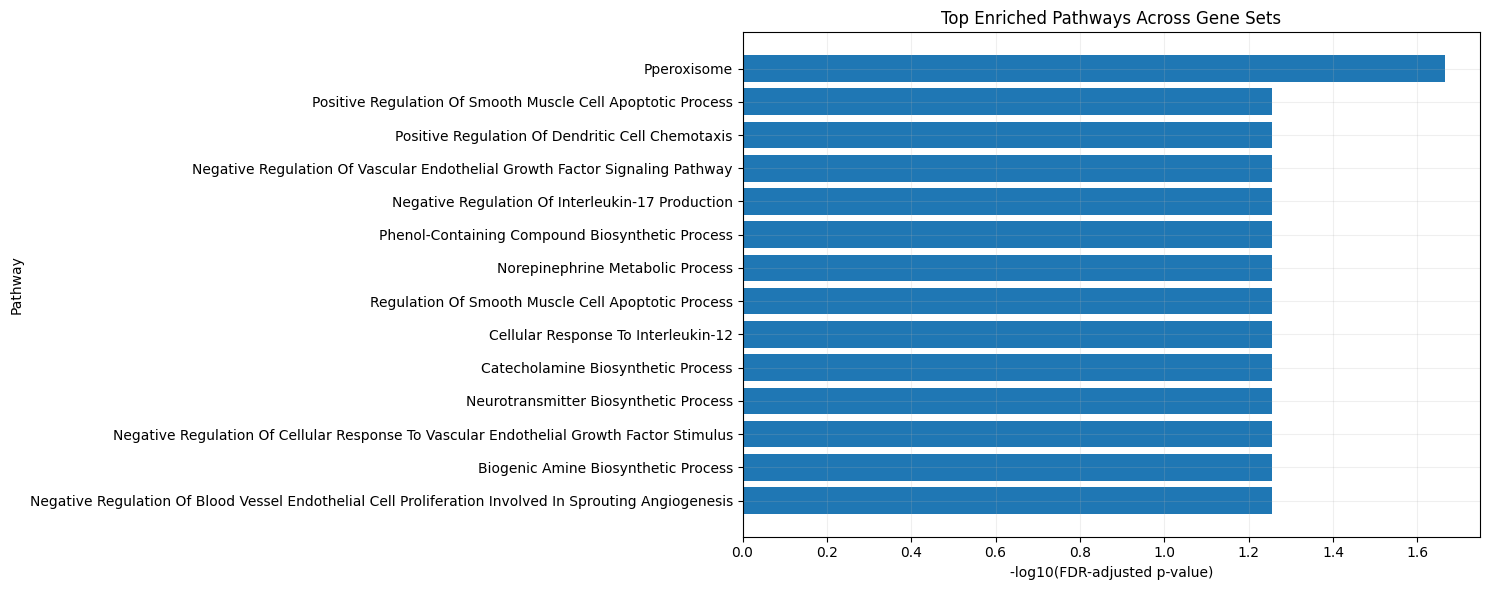

In [62]:
top_n = 15
top_pathways = (plot_df.sort_values("Adjusted P-value", ascending=True).head(top_n).copy())

plt.figure(figsize=(15, 6))
plt.barh(top_pathways["Term_short"], top_pathways["minus_log10_FDR"])
plt.xlabel("-log10(FDR-adjusted p-value)")
plt.ylabel("Pathway")
plt.title("Top Enriched Pathways Across Gene Sets")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, alpha=0.2)
plt.savefig(os.path.join(FIG_DIR, "top_enriched_pathways_overall.png"), dpi=300, bbox_inches="tight")
plt.show()

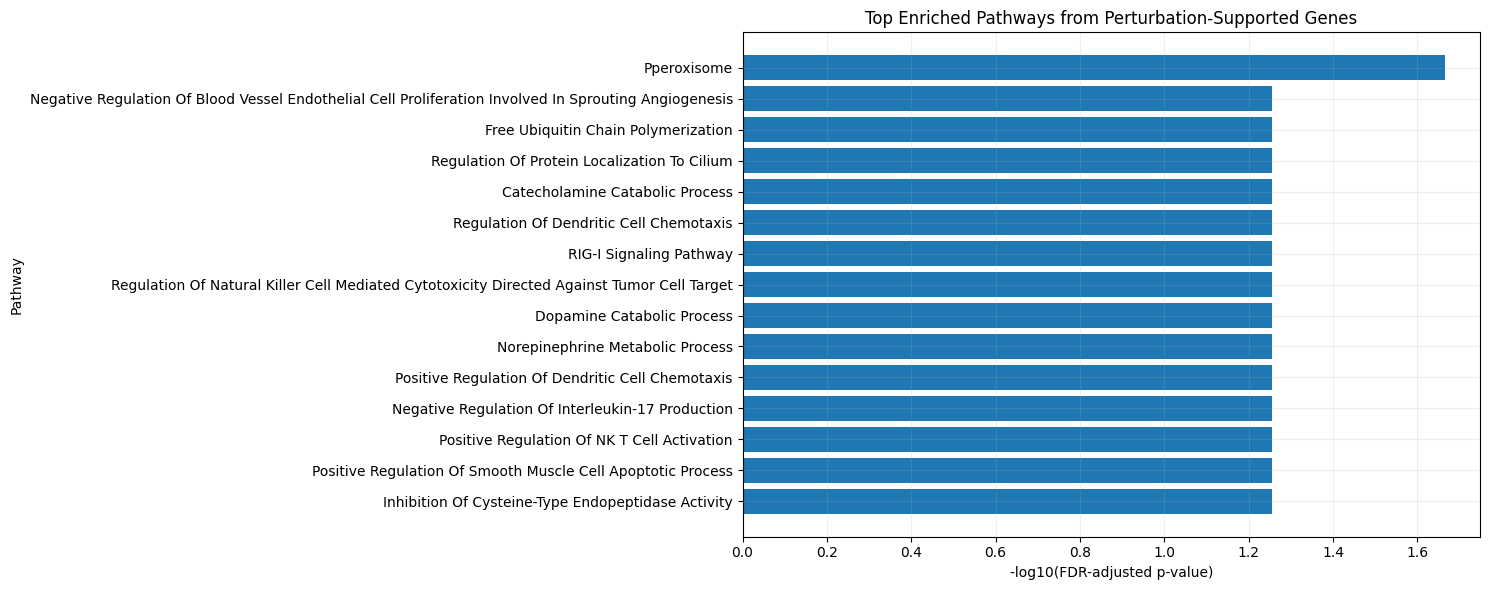

In [69]:
# Use perturbation-related sources only
perturb_sources = ["model_specific_perturb", "all_perturbation", "shared_attention_perturb"]

perturb_plot = plot_df[plot_df["source"].isin(perturb_sources)].copy()
# Remove duplicate pathway terms and keep best FDR
perturb_plot = (perturb_plot.sort_values("Adjusted P-value", ascending=True)
    .drop_duplicates(subset=["Term_short"], keep="first"))

top_perturb = perturb_plot.head(15)

plt.figure(figsize=(15, 6))
plt.barh(top_perturb["Term_short"], top_perturb["minus_log10_FDR"])
plt.xlabel("-log10(FDR-adjusted p-value)")
plt.ylabel("Pathway")
plt.title("Top Enriched Pathways from Perturbation-Supported Genes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, alpha=0.2)

plt.savefig(os.path.join(FIG_DIR, "top_enriched_pathways_perturbation.png"), dpi=300, bbox_inches="tight")
plt.show()

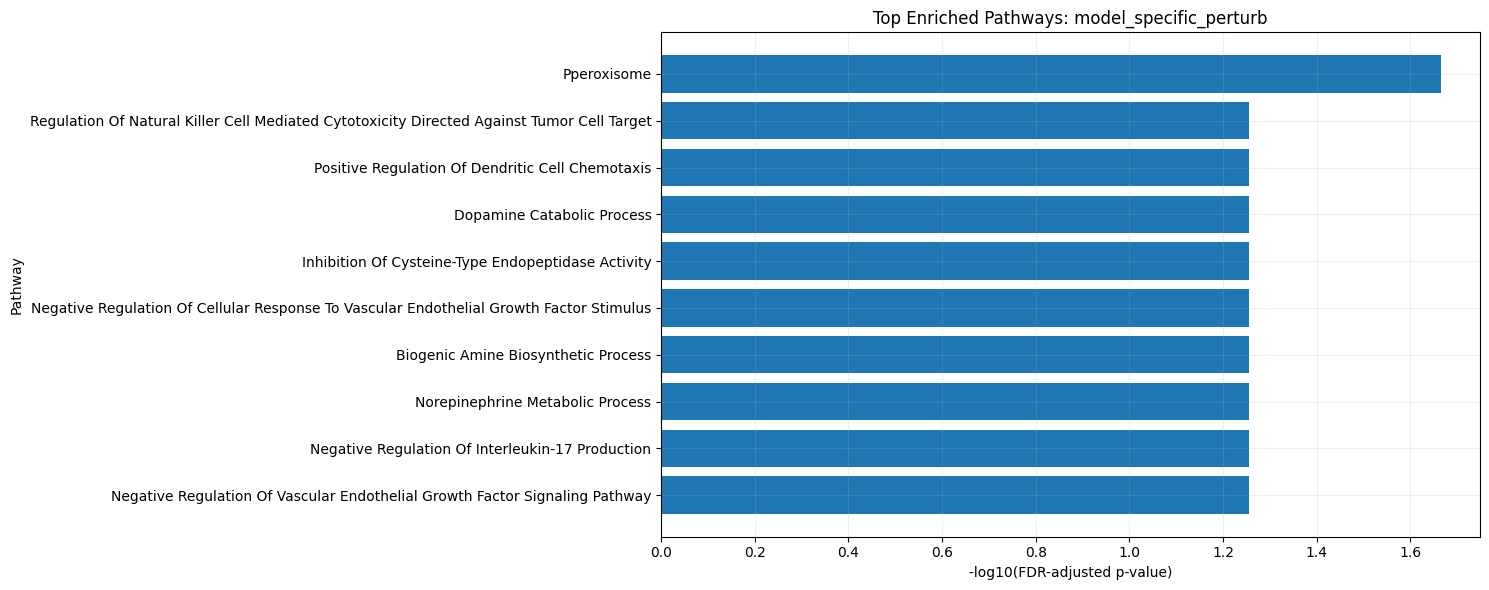

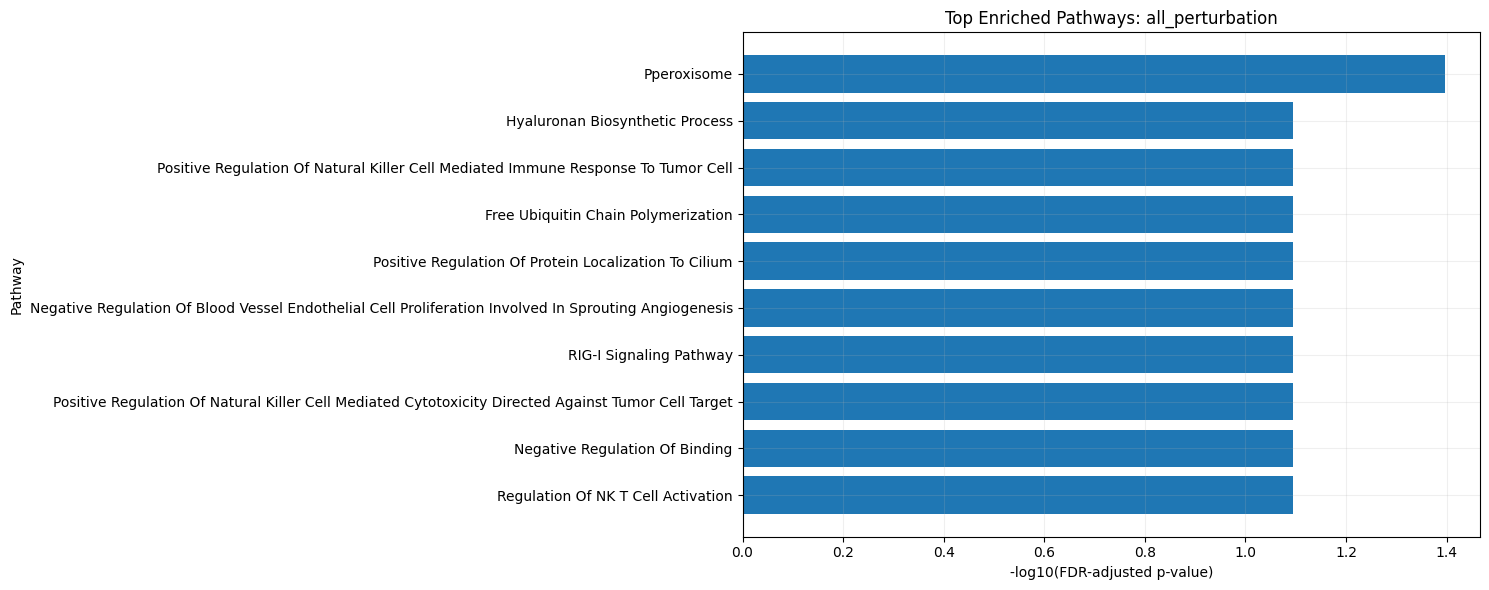

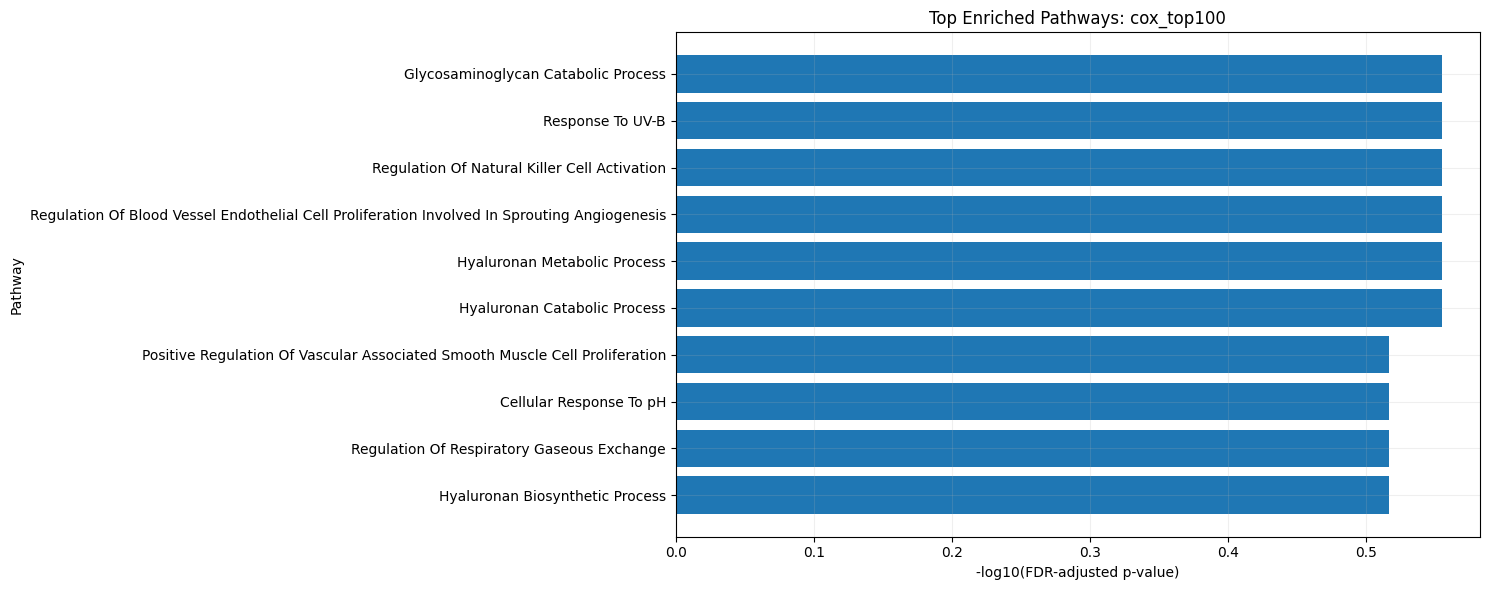

In [66]:
for source_name in plot_df["source"].dropna().unique():
    source_df = plot_df[plot_df["source"] == source_name].copy()

    if source_df.empty:
        continue

    source_top = (source_df.sort_values("Adjusted P-value", ascending=True).head(10))

    plt.figure(figsize=(15, 6))
    plt.barh(source_top["Term_short"], source_top["minus_log10_FDR"])
    plt.xlabel("-log10(FDR-adjusted p-value)")
    plt.ylabel("Pathway")
    plt.title(f"Top Enriched Pathways: {source_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.grid(True, alpha=0.2)
    save_name = f"top_pathways_{source_name}.png".replace("/", "_").replace(" ", "_")
    plt.savefig(os.path.join(FIG_DIR, save_name), dpi=300, bbox_inches="tight")
    plt.show()